# M11.0 — Hugging Face metadata export

Plan: [`plans/milestone_11/11_huggingface_artifacts_plan.md`](../../plans/milestone_11/11_huggingface_artifacts_plan.md).
Architecture: [`plans/00_architecture.md`](../../plans/00_architecture.md) §5.7.

Builds browseable parquet indexes + dataset-card README under
`data/huggingface_metadata/` for Hub configs **`m8_1`** and **`m10_illumination`**.
Requires local corpora under `data/generated/` (not regenerated here).
Hub publication uses zip archives (`m8_1.zip`, `m10_illumination.zip`);
preview JPEG/PNG bytes are embedded so the Dataset Viewer still works.


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,hf,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")


ROOT=.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## Export parquet + dataset card

One row per sequence (preview camera angle 0°). Float `.raw.tif` paths stay
as strings. JPEG/PNG **bytes** are embedded in Hub Image columns so the
Dataset Viewer works against zip-only corpora (`m8_1.zip`,
`m10_illumination.zip`).


In [2]:
from IPython.display import Markdown, display

from tomography_ml_huggingface import (
    METADATA_SUBDIR,
    export_huggingface_metadata,
)

out = export_huggingface_metadata(ROOT)
meta_root = ROOT / METADATA_SUBDIR
display(Markdown(f"Wrote indexes under `{display_path(meta_root)}`."))
for corpus, splits in out["counts"].items():
    display(Markdown(
        f"- **{corpus}**: train={splits['train']}, "
        f"validation={splits['validation']}, test={splits['test']}"
    ))


m8_1: 900 sequences (train=630, validation=135, test=135)
m10_illumination: 1500 sequences (train=1050, validation=228, test=222)
Wrote /Users/thomasbraschler/git/gummybear-tomography/data/huggingface_metadata/README.md


Wrote indexes under `data/huggingface_metadata`.

- **m8_1**: train=630, validation=135, test=135

- **m10_illumination**: train=1050, validation=228, test=222

## Smoke-check one viewer row


`bear_m8_low_000003`  regime=low  xyz=(2.721, 6.989, 6.681)

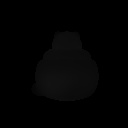

In [3]:
from io import BytesIO

import pyarrow.parquet as pq
from PIL import Image

train_pq = meta_root / "m8_1" / "train.parquet"
table = pq.read_table(train_pq)
row = {name: table.column(name)[0].as_py() for name in table.column_names}
observed = row["observed"]
assert observed["bytes"], "preview bytes must be embedded for the Hub Dataset Viewer"
img = Image.open(BytesIO(observed["bytes"]))
display(Markdown(
    f"`{row['sequence_id']}`  regime={row['optical_regime']}  "
    f"xyz=({row['particle_x']:.3f}, {row['particle_y']:.3f}, {row['particle_z']:.3f})"
))
display(img)


## Hub upload reminder

Upload `data/huggingface_metadata/` together with the zip archives
`data/generated/m8_1.zip` and `data/generated/m10_illumination.zip`.
Do **not** upload extracted trees: Image columns already contain JPEG/PNG
bytes for the Dataset Viewer. Place the dataset-card README at the Hub
dataset root (or keep the same relative paths as in the YAML `configs`).
Checkpoints under `checkpoints/` are optional companion artefacts.
Unzip locally only when you need the full multi-view float TIFF stacks.
